In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.evals.eval_utils import load_session_arrays
from src.evals.metrics import truth_input_decoding_memory_network

run_dir = Path("..") / "data" / "memory_network_h512_n0.5_id2606221443"
h5_path = run_dir / "data.h5"
area_key = "area-A0"

c:\Users\wlo12\OneDrive\Desktop\Projects\dgn\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
arrays = load_session_arrays(h5_path)
area_a0 = arrays[area_key]

with h5py.File(h5_path, "r") as h:
    attrs = dict(h["0"][area_key].attrs)

decode_r2 = truth_input_decoding_memory_network(arrays, arrays, run_dir / "configs")

trial_std = area_a0.std(axis=1)
neuron_range = area_a0.max(axis=1) - area_a0.min(axis=1)


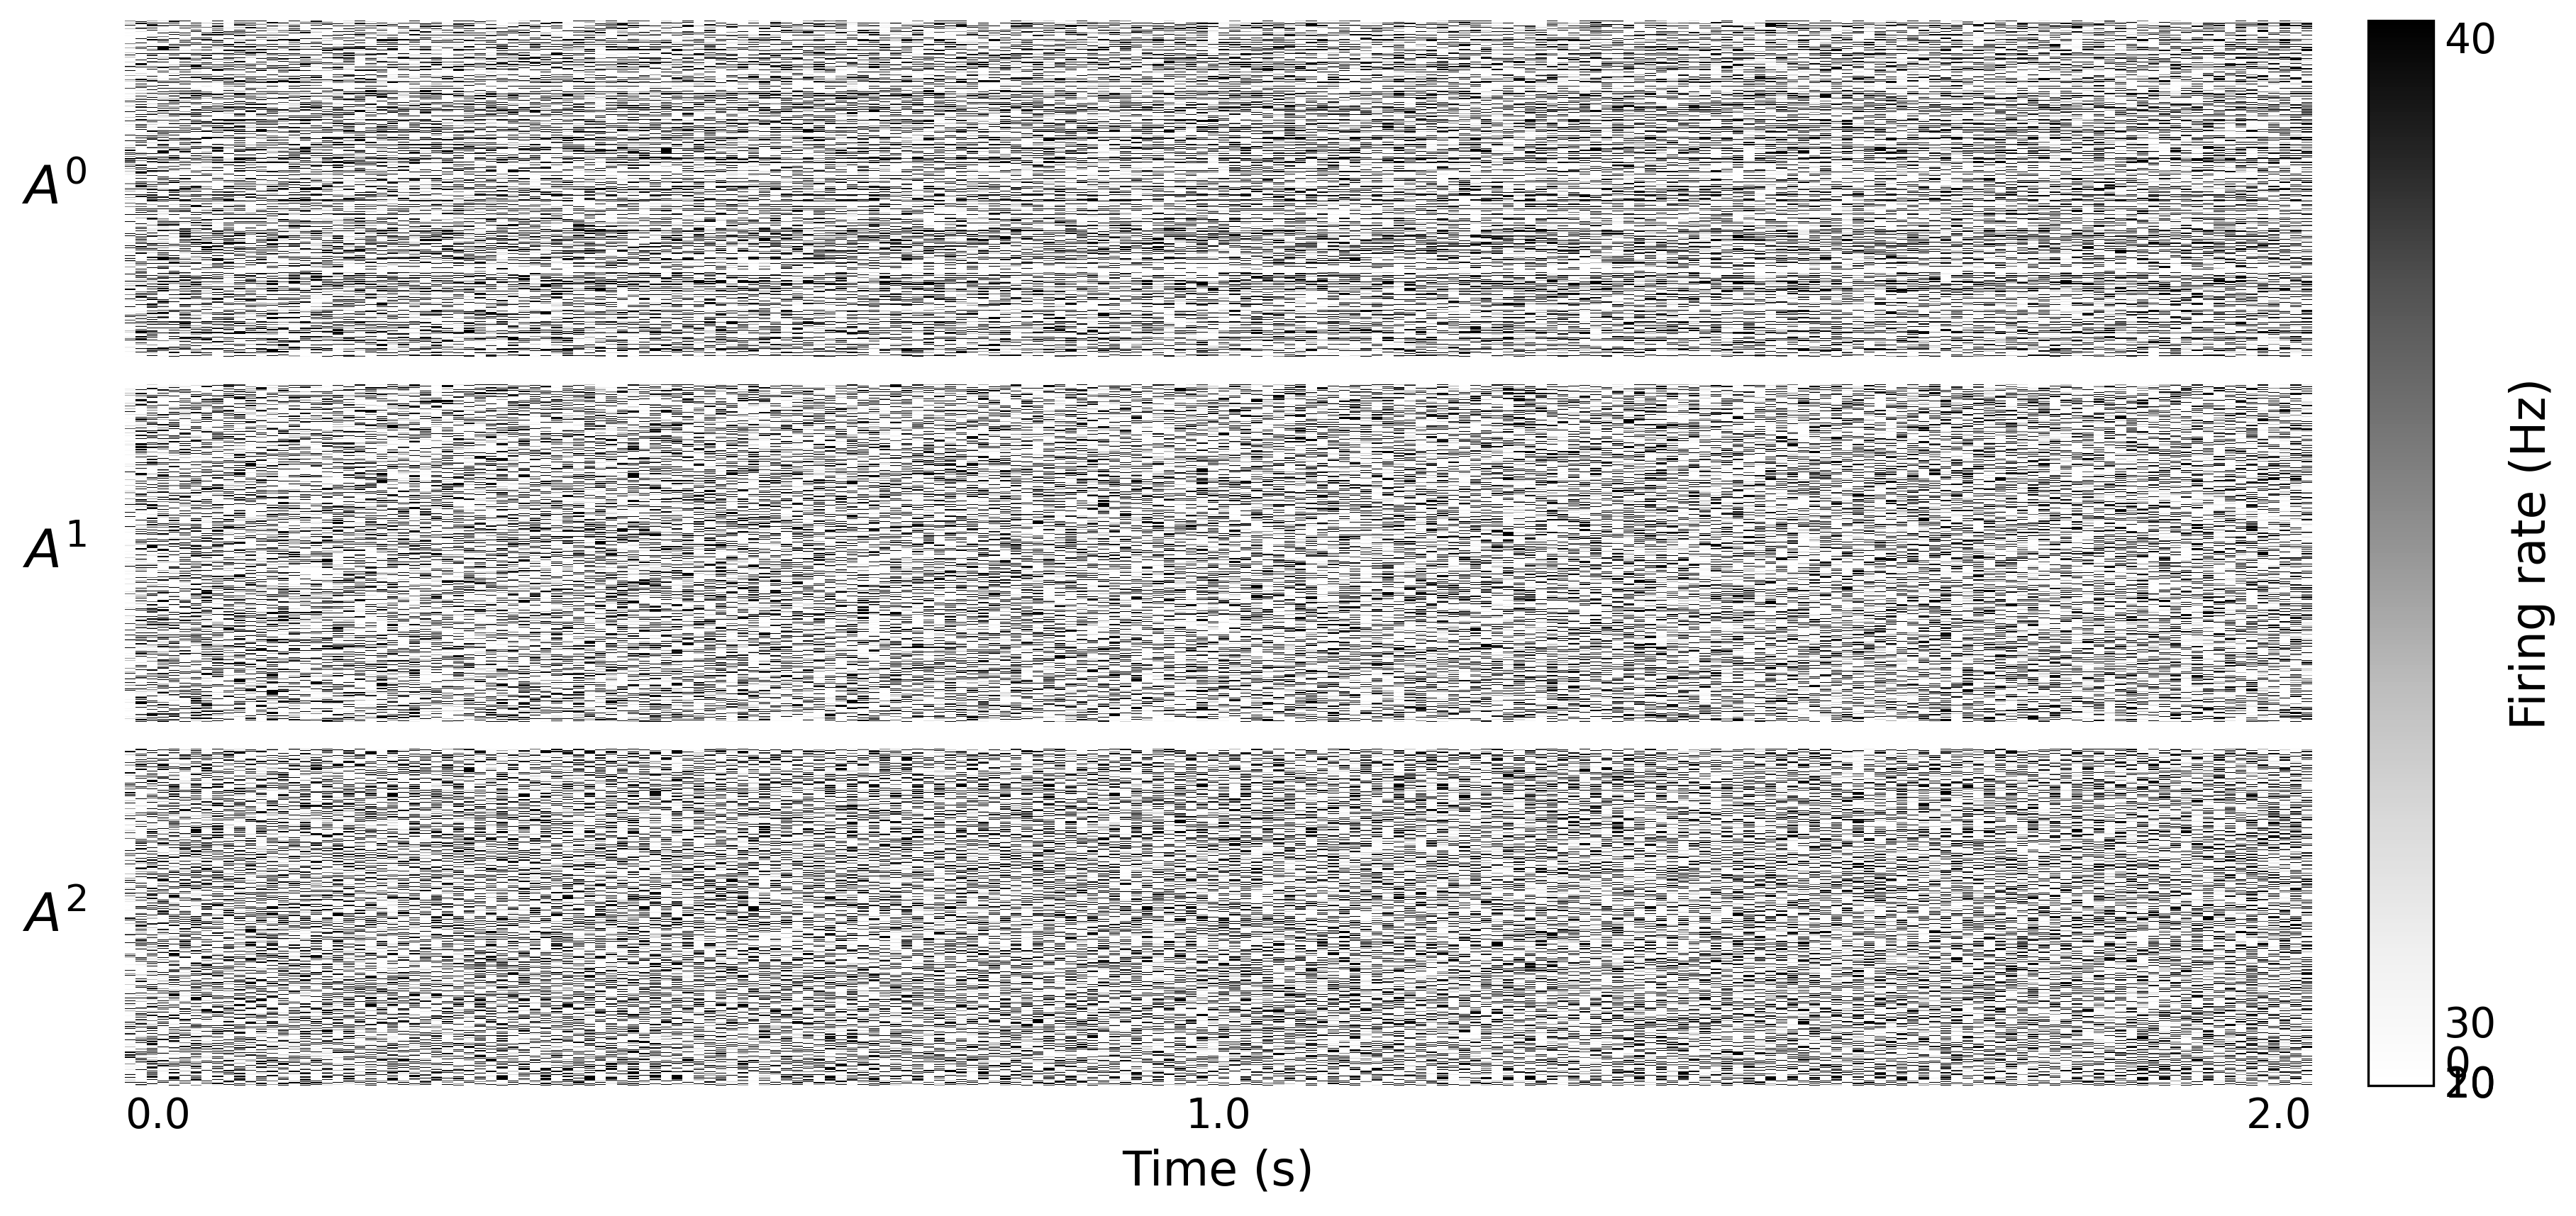

In [11]:
# Underlying firing rates by area (grayscale)

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

AREAS = ["A0", "A1", "A2"]
AREA_LABELS = [r"$A^0$", r"$A^1$", r"$A^2$"]
TRIAL_IDX = 0
RATE_MAX = 40.0
BIN_DT_S = 0.01  # 10 ms bins -> 200 steps = 2 s

with h5py.File(run_dir / "gaussian.h5", "r") as h:
    continuous = {a: h["0"][f"area-{a}"][TRIAL_IDX] for a in AREAS}  # (T, N)

rates = {
    a: np.clip(RATE_MAX * (continuous[a] + 1.0) / 2.0, 0.0, RATE_MAX)
    for a in AREAS
}

T = continuous["A0"].shape[0]
time_s = np.arange(T) * BIN_DT_S

fig = plt.figure(figsize=(14, 6.5), dpi=300)
gs = fig.add_gridspec(
    len(AREAS),
    2,
    width_ratios=[1.0, 0.03],
    wspace=0.05,
    hspace=0.08,
)
axes = [fig.add_subplot(gs[i, 0]) for i in range(len(AREAS))]
cax = fig.add_subplot(gs[:, 1])

norm = PowerNorm(gamma=10, vmin=0.0, vmax=RATE_MAX)
im = None
for ax, area, label in zip(axes, AREAS, AREA_LABELS):
    Z = rates[area].T  # (N, T)
    im = ax.imshow(
        Z,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        cmap="Greys",
        norm=norm,
        extent=[time_s[0], time_s[-1] + BIN_DT_S, 0, Z.shape[0]],
    )
    ax.set_ylabel(label, rotation=0, labelpad=24, va="center", fontsize=18, fontweight="bold")
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel("Time (s)", fontsize=16)
axes[-1].set_xlim(time_s[0], time_s[-1] + BIN_DT_S)
axes[-1].set_xticks([0.0, 1.0, 2.0])
axes[-1].set_xticklabels(["0.0", "1.0", "2.0"])
axes[-1].tick_params(axis="x", which="both", length=0, labelbottom=True, labelsize=14)
for tick, ha in zip(axes[-1].xaxis.get_majorticklabels(), ["left", "center", "right"]):
    tick.set_horizontalalignment(ha)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Firing rate (Hz)", fontsize=16)
cbar.set_ticks([0, 10, 20, 30, 40])
cbar.ax.tick_params(labelsize=14, length=0)
cbar_labels = cbar.ax.yaxis.get_majorticklabels()
if len(cbar_labels) >= 2:
    cbar_labels[0].set_verticalalignment("bottom")
    cbar_labels[-1].set_verticalalignment("top")
    for tick in cbar_labels[1:-1]:
        tick.set_verticalalignment("center")

plt.show()


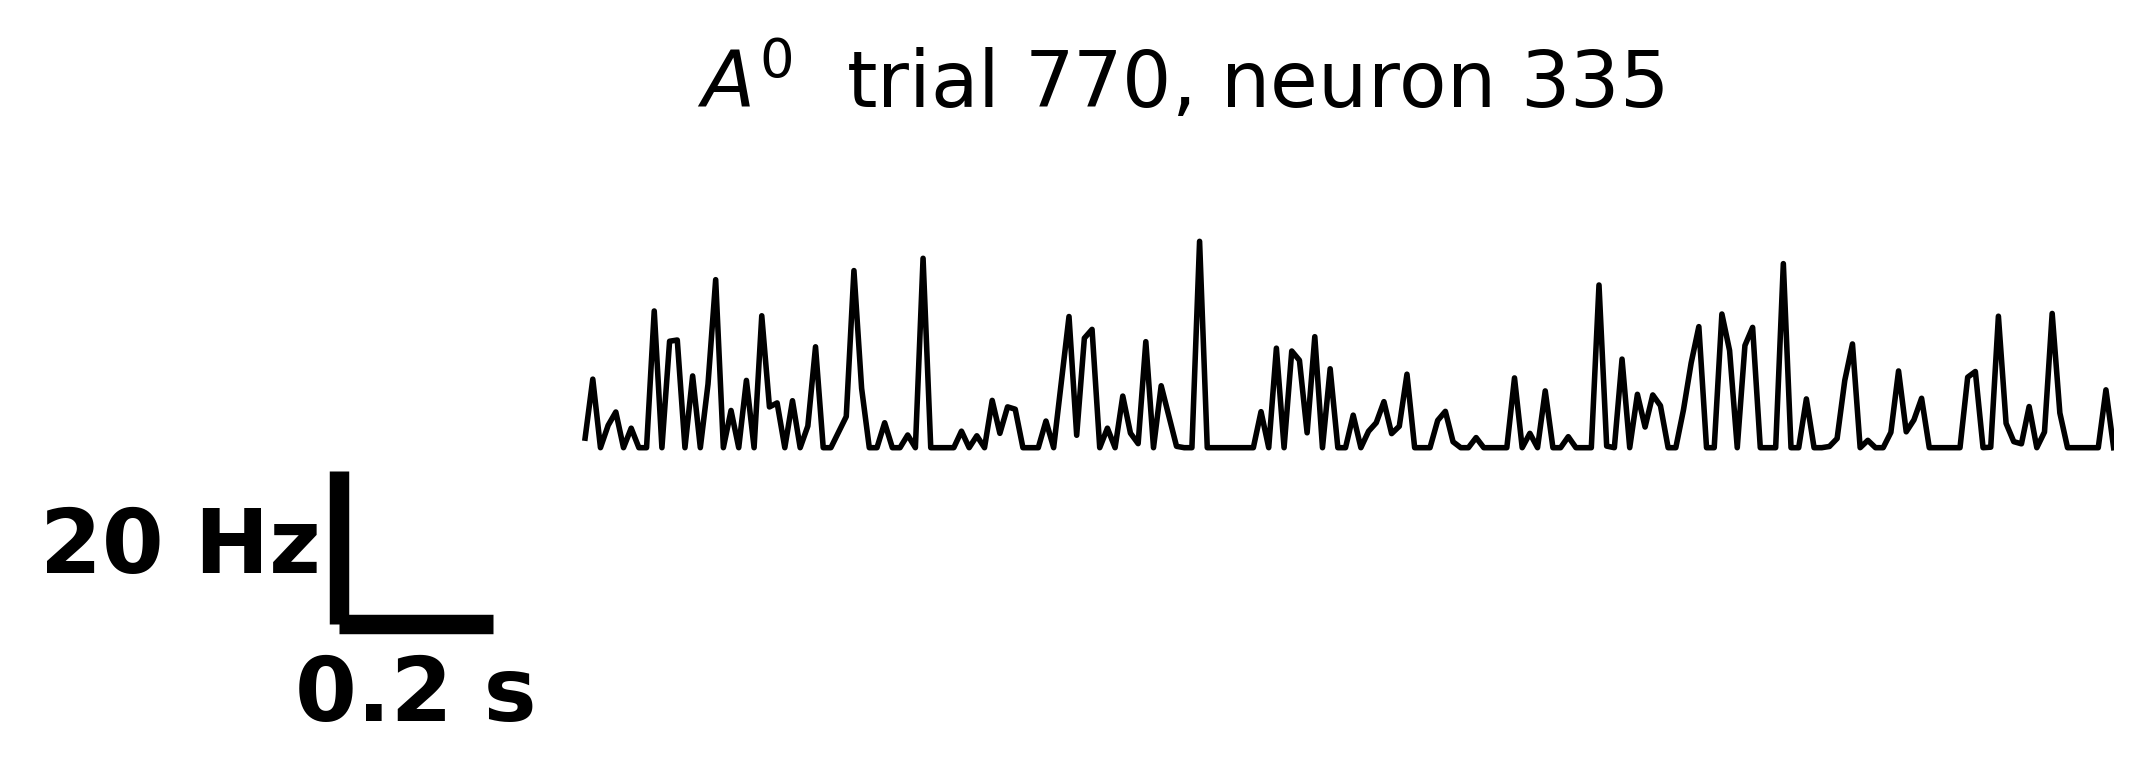

In [75]:
# Firing rate trace: random trial, random neuron (matched scale bars, no axes)

import matplotlib.pyplot as plt

AREA = "A0"
RATE_MAX = 40.0
BIN_DT_S = 0.01
TIME_BAR_S = 0.2    # larger fraction of the 2 s trial
RATE_BAR_HZ = 20.0  # larger fraction of the 0–40 Hz range
rng = np.random.default_rng()  # re-run cell for a new draw

with h5py.File(run_dir / "gaussian.h5", "r") as h:
    act = h["0"][f"area-{AREA}"]  # (trials, time, neurons)
    n_trials, n_time, n_neurons = act.shape
    trial_idx = int(rng.integers(n_trials))
    neuron_idx = int(rng.integers(n_neurons))
    trial_idx, neuron_idx = 770, 335
    activity = act[trial_idx, :, neuron_idx]

rates = np.clip(RATE_MAX * (activity + 1.0) / 2.0, 0.0, RATE_MAX)
time_s = np.arange(n_time) * BIN_DT_S
duration_s = float(time_s[-1])

# Compact plot; scale bars + labels carry the visual weight (NeurIPS-friendly)
fig, ax = plt.subplots(figsize=(5.5, 2.2), dpi=400)
ax.plot(time_s, rates, color="black", lw=1.0)

# Generous gutter so large scale bars sit clear of the trace
x_pad = TIME_BAR_S * 2.2
y_pad = RATE_BAR_HZ * 1.6
ax.set_xlim(-x_pad, duration_s)
ax.set_ylim(-y_pad, RATE_MAX)
ax.set_aspect(TIME_BAR_S / RATE_BAR_HZ, adjustable="box")
ax.set_axis_off()

# L-shaped scale bars — thick, labeled large
x0, y0 = -TIME_BAR_S * 1.6, -RATE_BAR_HZ * 1.15
ax.plot([x0, x0 + TIME_BAR_S], [y0, y0], color="black", lw=3.5, solid_capstyle="butt", clip_on=False)
ax.plot([x0, x0], [y0, y0 + RATE_BAR_HZ], color="black", lw=3.5, solid_capstyle="butt", clip_on=False)
ax.text(
    x0 + 0.5 * TIME_BAR_S,
    y0 - 0.18 * RATE_BAR_HZ,
    f"{TIME_BAR_S:g} s",
    ha="center",
    va="top",
    fontsize=16,
    fontweight="bold",
)
ax.text(
    x0 - 0.12 * TIME_BAR_S,
    y0 + 0.5 * RATE_BAR_HZ,
    f"{RATE_BAR_HZ:g} Hz",
    ha="right",
    va="center",
    fontsize=16,
    fontweight="bold",
)

ax.set_title(
    rf"${AREA[0]}^{AREA[1]}$  trial {trial_idx}, neuron {neuron_idx}",
    fontsize=14,
    pad=6,
)
fig.tight_layout()
plt.show()


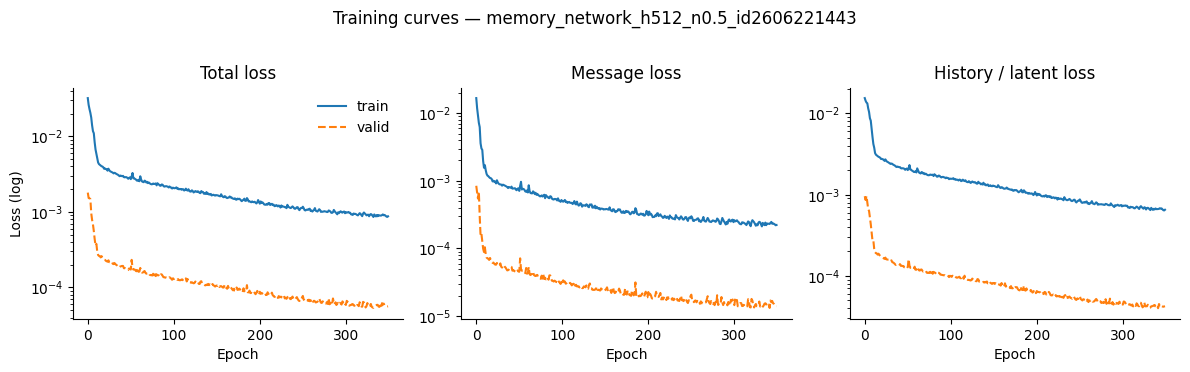

In [2]:
# Training loss curves from TensorBoard events

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(run_dir), size_guidance={"scalars": 0})
ea.Reload()

epoch_events = ea.Scalars("epoch")
# Map training step -> epoch (same step may appear twice: train + valid)
step_to_epoch = {e.step: e.value for e in epoch_events}


def scalar_df(tag):
    rows = []
    for e in ea.Scalars(tag):
        rows.append({"step": e.step, "epoch": step_to_epoch.get(e.step, e.step), "value": e.value})
    return pd.DataFrame(rows)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True)
panels = [
    ("loss", "Total loss"),
    ("loss_mesg", "Message loss"),
    ("loss_hist", "History / latent loss"),
]

for ax, (suffix, title) in zip(axes, panels):
    for split, color, ls in [("train", "C0", "-"), ("valid", "C1", "--")]:
        tag = f"{split}/{suffix}"
        df = scalar_df(tag)
        ax.plot(df["epoch"], df["value"], color=color, ls=ls, lw=1.5, label=split)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Loss (log)")
axes[0].legend(frameon=False)
fig.suptitle(f"Training curves — {run_dir.name}", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


lag=2, memory=2
mean message R²: 0.9849
mean latent  R²: 0.9562


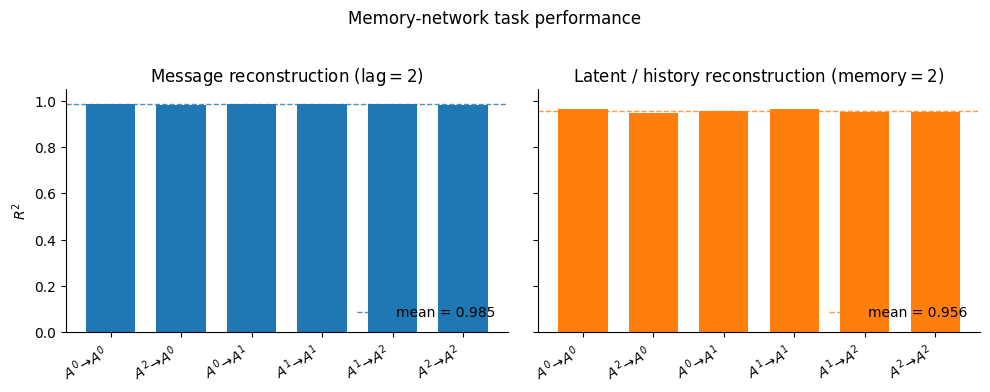

In [35]:
# Task performance: message + latent reconstruction R² (training objectives)

import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

hps = yaml.safe_load((run_dir / "hparams.yaml").read_text())
connectome = np.asarray(hps["connectome"], dtype=int)
ranks = np.asarray(hps["ranks"], dtype=int)
lag = int(hps["lag"])
memory = int(hps["memory"])
n_areas = connectome.shape[0]


def rank_idx(ranks, area):
    return list(range(int(ranks[:area].sum()), int(ranks[: area + 1].sum())))


def edge_channel_labels(connectome, ranks):
    labels = []
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                for k in range(int(ranks[ib])):
                    lab = rf"$A^{ib}\!\to\!A^{ia}$"
                    if ranks[ib] > 1:
                        lab += f"[{k}]"
                    labels.append(lab)
    return labels


def build_inp_extended(inp, connectome, ranks):
    parts = []
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                parts.append(inp[..., rank_idx(ranks, ib)])
    return np.concatenate(parts, axis=-1)


def build_inp_hist(inp, connectome, ranks, memory):
    parts = []
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                for ic in rank_idx(ranks, ib):
                    for ti in range(memory):
                        parts.append(inp[:, ti : -(memory - ti), ic : ic + 1])
    return np.concatenate(parts, axis=-1)


inp = arrays["truth-inp"]
mesgs = arrays["message-mesgs"]
latents = arrays["message-latents"]

y_msg = build_inp_extended(inp, connectome, ranks)[:, :-lag]
yhat_msg = mesgs[:, lag:]
r2_msg = np.array(
    [r2_score(y_msg[..., i].ravel(), yhat_msg[..., i].ravel()) for i in range(y_msg.shape[-1])]
)

y_lat = build_inp_hist(inp, connectome, ranks, memory)[:, : -lag * 2]
yhat_lat = latents[:, memory + lag * 2 :]
r2_lat = np.array(
    [r2_score(y_lat[..., i].ravel(), yhat_lat[..., i].ravel()) for i in range(y_lat.shape[-1])]
)

# Average latent R² over memory slots per edge channel
r2_lat_by_edge = r2_lat.reshape(-1, memory).mean(axis=1)
edge_labels = edge_channel_labels(connectome, ranks)

print(f"lag={lag}, memory={memory}")
print(f"mean message R²: {r2_msg.mean():.4f}")
print(f"mean latent  R²: {r2_lat.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
x = np.arange(len(edge_labels))

axes[0].bar(x, r2_msg, color="C0", width=0.7)
axes[0].axhline(r2_msg.mean(), color="C0", ls="--", lw=1, alpha=0.8, label=f"mean = {r2_msg.mean():.3f}")
axes[0].set_xticks(x)
axes[0].set_xticklabels(edge_labels, rotation=30, ha="right")
axes[0].set_ylabel(r"$R^2$")
axes[0].set_title(rf"Message reconstruction (lag$={lag}$)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(frameon=False, loc="lower right")

axes[1].bar(x, r2_lat_by_edge, color="C1", width=0.7)
axes[1].axhline(r2_lat.mean(), color="C1", ls="--", lw=1, alpha=0.8, label=f"mean = {r2_lat.mean():.3f}")
axes[1].set_xticks(x)
axes[1].set_xticklabels(edge_labels, rotation=30, ha="right")
axes[1].set_title(rf"Latent / history reconstruction (memory$={memory}$)")
axes[1].legend(frameon=False, loc="lower right")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Memory-network task performance", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


saved


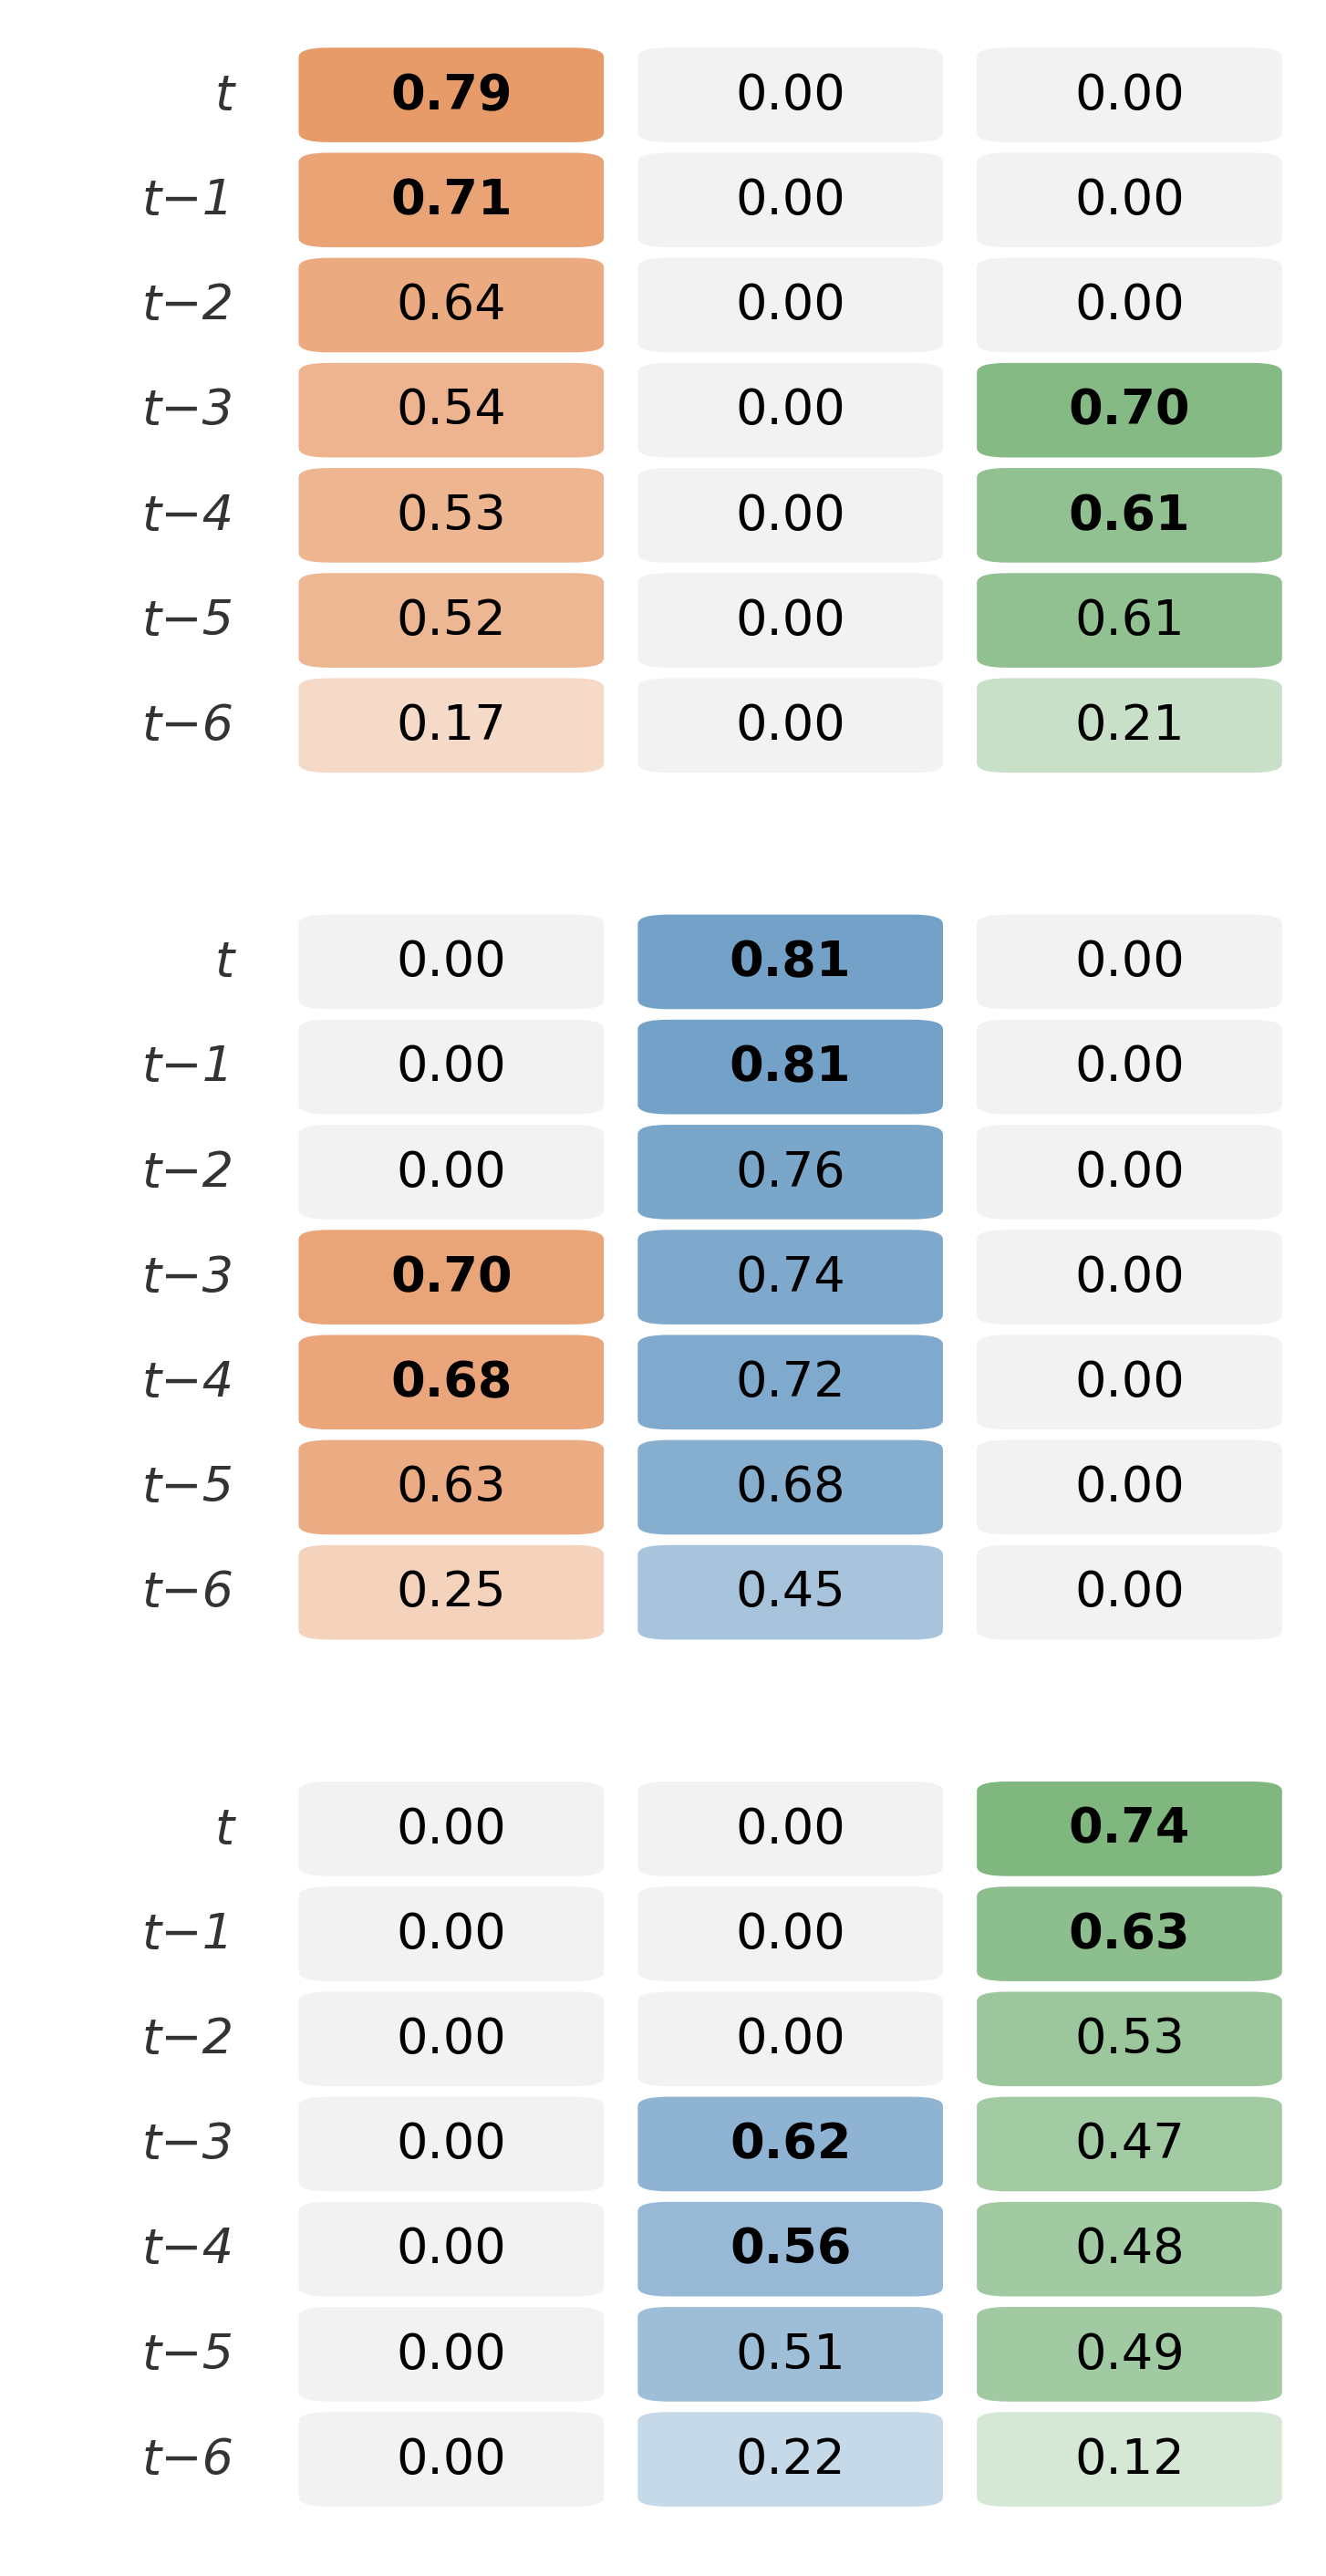

In [33]:
# Lag decoding tables: decode s1/s2/s3 from each region's hidden activity

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

MAX_LAG = 6
AREAS = ["A0", "A1", "A2"]
SIGNAL_LABELS = [r"$s^1$", r"$s^2$", r"$s^3$"]
SIGNAL_AREAS = [r"$A^0$", r"$A^1$", r"$A^2$"]
SIGNAL_COLORS = ["#E8923F", "#5B9BD5", "#70AD47"]
truth_inp = arrays["truth-inp"]


def lag_decode_r2(hidden, target, lag, test_size=0.2, random_state=0):
    """Decode target at time t-lag from hidden activity at time t."""
    if lag > 0:
        X = hidden[:, lag:, :]
        y = target[:, :-lag]
    else:
        X = hidden
        y = target
    y = y[..., None]
    train_idx, test_idx = train_test_split(
        np.arange(X.shape[0]), test_size=test_size, random_state=random_state
    )
    reg = Ridge(alpha=0.0)
    reg.fit(X[train_idx].reshape(-1, X.shape[-1]), y[train_idx].reshape(-1, 1))
    y_pred = reg.predict(X[test_idx].reshape(-1, X.shape[-1]))
    return float(r2_score(y[test_idx].reshape(-1, 1), y_pred))


scores = {}
for area in AREAS:
  hidden = arrays[f"area-{area}"]
  mat = np.zeros((MAX_LAG + 1, 3))
  for lag in range(MAX_LAG + 1):
    for sig in range(3):
      mat[lag, sig] = lag_decode_r2(hidden, truth_inp[..., sig], lag)
  scores[area] = mat

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgb


MAX_LAG = 6
AREAS = ["A0", "A1", "A2"]
# SIGNAL_COLORS = ["#E07B39", "#3E7CB1", "#4C9A4C"]   # orange, blue, green
# Slightly lighter
SIGNAL_COLORS = ["#E07B39", "#4B86B8", "#4C9A4C"]
GRID_COLOR = "#F2F2F2"

row_labels = ["t"] + [f"t\u2212{lag}" for lag in range(1, MAX_LAG + 1)]
col_labels = ["s\u00B9", "s\u00B2", "s\u00B3"]
col_sub = ["(own)", "(from A\u00B9)", "(from A\u00B2)"]
area_labels = ["A\u00B9", "A\u00B2", "A\u00B3"]


def fmt(v):
    return "0.00" if abs(v) < 5e-3 else f"{v:.2f}"


n_rows = MAX_LAG + 1
n_cols = 3

ZERO_BG = "#F2F2F2"  # subtle background for near-zero cells

fig, axes = plt.subplots(len(AREAS), 1, figsize=(5.6, 9.6), facecolor="white", dpi=300)
fig.subplots_adjust(left=0.14, right=0.97, top=0.98, bottom=0.02, hspace=0.10)

cell_w, cell_h = 1.0, 1.0
gap = 0.10  # gap between cells, in cell units

for a_idx, (ax, area) in enumerate(zip(axes, AREAS)):
    ax.set_xlim(-0.75, n_cols)
    ax.set_ylim(-0.15, n_rows + 0.35)
    ax.invert_yaxis()
    ax.set_axis_off()
    ax.set_facecolor("white")

    mat = scores[area]

    # Find the top 2 rows in each column
    top2 = set()
    for c in range(mat.shape[1]):
        rows = np.argpartition(mat[:, c], -2)[-2:]
        top2.update((r, c) for r in rows)
        
    # row labels
    for r in range(n_rows):
        ry = r + 0.5
        # weight = "bold" if r == 0 else "normal"
        ax.text(-0.14, ry, row_labels[r], ha="right", va="center",
                 fontsize=13, fontweight="normal", color="#333333",
                 style="italic")

    # cells
    for r in range(n_rows):
        for c in range(n_cols):
            val = float(mat[r, c])
            intensity = np.clip(val, 0.0, 1.0)
            rgb = to_rgb(SIGNAL_COLORS[c])

            x = c + gap / 2
            y = r + gap / 2
            w = cell_w - gap
            h = cell_h - gap

            if intensity < 0.05:
                facecolor = ZERO_BG
                alpha_val = 0.0
            else:
                alpha_val = 0.14 + 0.78 * intensity
                facecolor = (rgb[0], rgb[1], rgb[2], alpha_val)

            box = FancyBboxPatch(
                (x, y), w, h,
                boxstyle="round,pad=0,rounding_size=0.09",
                linewidth=0,
                facecolor=facecolor,
                zorder=2,
            )
            ax.add_patch(box)

            # text_color = "#111111" if intensity < 0.72 else "#ffffff" if alpha_val > 0.75 else "#111111"
            ax.text(c + 0.5, r + 0.5, fmt(val), ha="center", va="center",
                     fontsize=13,
                     fontweight="bold" if (r, c) in top2 and intensity > 0.00 else "normal",
                    zorder=3)

    # separator line between panels
    # if a_idx < len(AREAS) - 1:
    #     ax.plot([-0.75, n_cols], [n_rows + 0.05, n_rows + 0.05],
    #              transform=ax.transData, color="#E3E3E3", linewidth=1.0,
    #              clip_on=False)

print("saved")

A0 incoming ch [0, 1] R²@lag 2 [ 9.88808847e-01 -9.41762263e-05  9.80629243e-01]
A1 incoming ch [2, 3] R²@lag 2 [ 9.88808972e-01  9.86017614e-01 -5.67151374e-05]
A2 incoming ch [4, 5] R²@lag 2 [-9.04445556e-05  9.86017743e-01  9.80628448e-01]


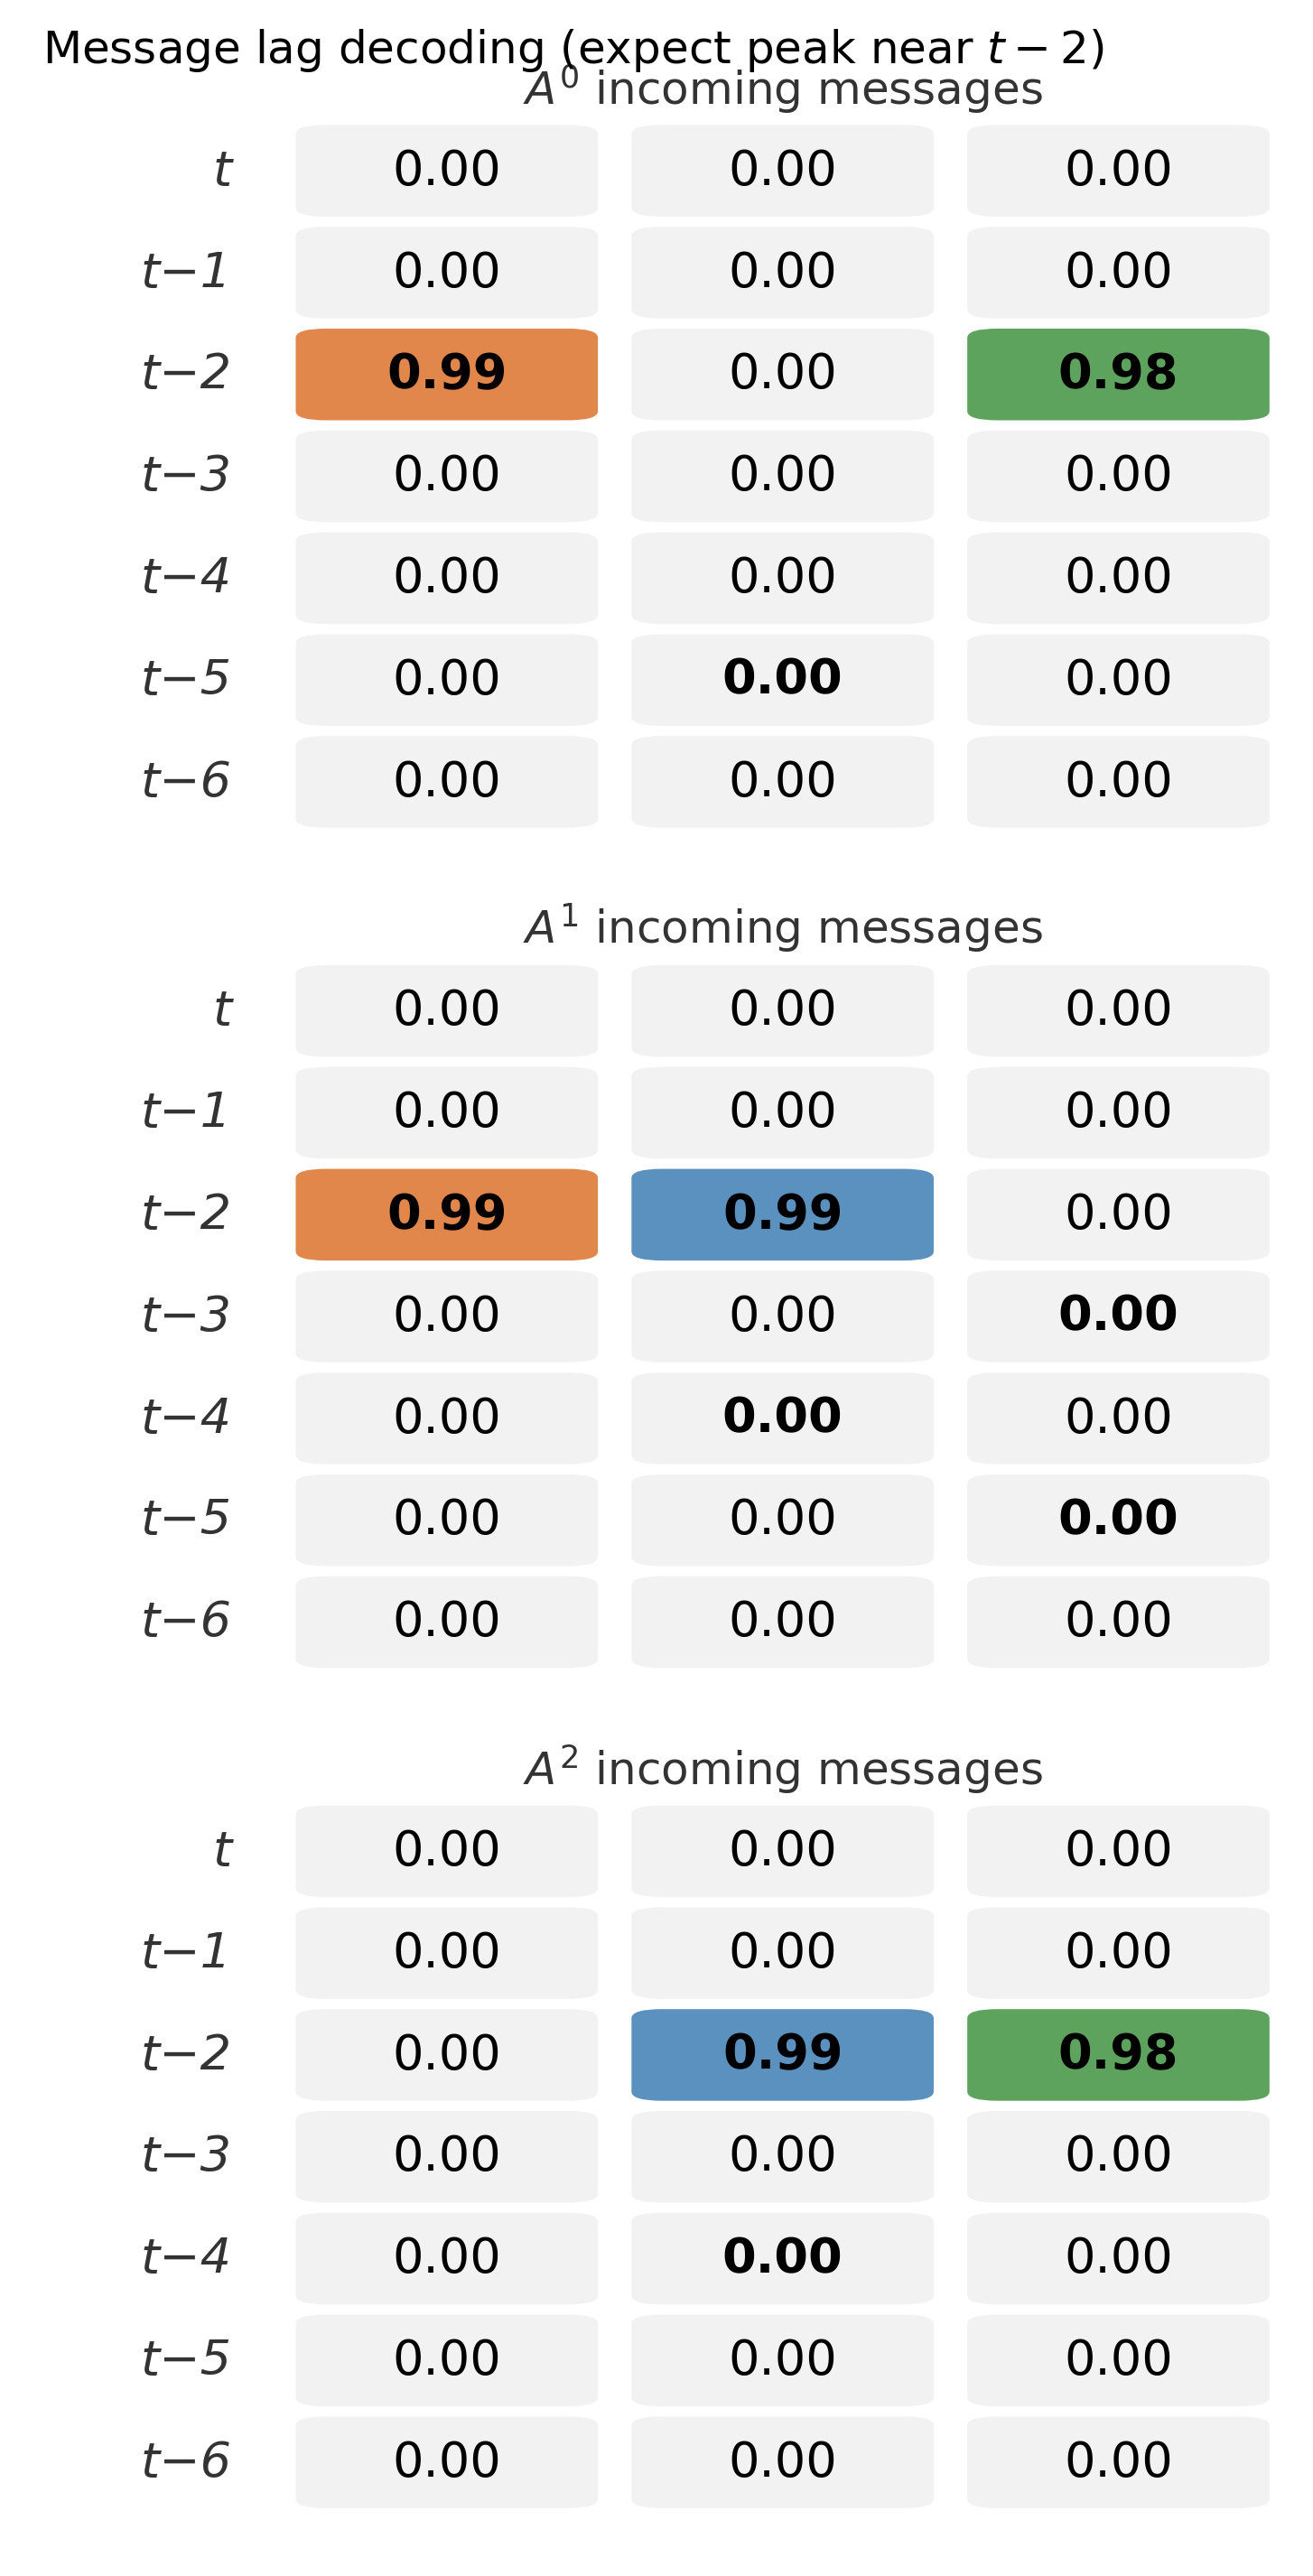

In [40]:
# Lag decoding tables for messages (same layout as hidden tables)
# Expected: peaks near t−lag (= t−2), not t−3 — messages are trained to lagged inputs directly

import yaml
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgb

hps = yaml.safe_load((run_dir / "hparams.yaml").read_text())
connectome = np.asarray(hps["connectome"], dtype=int)
ranks = np.asarray(hps["ranks"], dtype=int)
cfg_lag = int(hps["lag"])
mesgs = arrays["message-mesgs"]

# Flatten order matches models.py: effectome.flatten() with effectome[ia, ib] = ranks[ib] * C[ia, ib]
def incoming_mesg_indices(target_area):
    idxs, cursor = [], 0
    for ia in range(connectome.shape[0]):
        for ib in range(connectome.shape[0]):
            n_ch = int(ranks[ib]) if connectome[ia, ib] else 0
            if ia == target_area and n_ch > 0:
                idxs.extend(range(cursor, cursor + n_ch))
            cursor += n_ch
    return idxs


msg_scores = {}
for a_idx, area in enumerate(AREAS):
    feats = mesgs[..., incoming_mesg_indices(a_idx)]
    mat = np.zeros((MAX_LAG + 1, 3))
    for lag in range(MAX_LAG + 1):
        for sig in range(3):
            mat[lag, sig] = lag_decode_r2(feats, truth_inp[..., sig], lag)
    msg_scores[area] = mat
    print(area, "incoming ch", incoming_mesg_indices(a_idx), "R²@lag", cfg_lag, mat[cfg_lag])

# --- same visual style as hidden lag tables ---
row_labels = ["t"] + [f"t−{lag}" for lag in range(1, MAX_LAG + 1)]
n_rows, n_cols = MAX_LAG + 1, 3
ZERO_BG = "#F2F2F2"
cell_w, cell_h, gap = 1.0, 1.0, 0.10


def fmt(v):
    return "0.00" if abs(v) < 5e-3 else f"{v:.2f}"


fig, axes = plt.subplots(len(AREAS), 1, figsize=(5.6, 9.6), facecolor="white", dpi=300)
fig.subplots_adjust(left=0.14, right=0.97, top=0.96, bottom=0.02, hspace=0.10)

for a_idx, (ax, area) in enumerate(zip(axes, AREAS)):
    ax.set_xlim(-0.75, n_cols)
    ax.set_ylim(-0.15, n_rows + 0.35)
    ax.invert_yaxis()
    ax.set_axis_off()
    ax.set_facecolor("white")

    mat = msg_scores[area]
    top2 = set()
    for c in range(mat.shape[1]):
        rows = np.argpartition(mat[:, c], -2)[-2:]
        top2.update((r, c) for r in rows)

    ax.text(1.5, -0.05, rf"{SIGNAL_AREAS[a_idx]} incoming messages", ha="center", va="bottom",
            fontsize=12, color="#333333")

    for r in range(n_rows):
        ax.text(-0.14, r + 0.5, row_labels[r], ha="right", va="center",
                fontsize=13, color="#333333", style="italic")

    for r in range(n_rows):
        for c in range(n_cols):
            val = float(mat[r, c])
            intensity = np.clip(val, 0.0, 1.0)
            rgb = to_rgb(SIGNAL_COLORS[c])
            x, y = c + gap / 2, r + gap / 2
            w, h = cell_w - gap, cell_h - gap
            if intensity < 0.05:
                facecolor = ZERO_BG
            else:
                facecolor = (*rgb, 0.14 + 0.78 * intensity)
            ax.add_patch(FancyBboxPatch(
                (x, y), w, h,
                boxstyle="round,pad=0,rounding_size=0.09",
                linewidth=0, facecolor=facecolor, zorder=2,
            ))
            ax.text(c + 0.5, r + 0.5, fmt(val), ha="center", va="center", fontsize=13,
                    fontweight="bold" if (r, c) in top2 and intensity > 0 else "normal",
                    zorder=3)

fig.suptitle(rf"Message lag decoding (expect peak near $t-{cfg_lag}$)", fontsize=12, y=0.99)
plt.show()


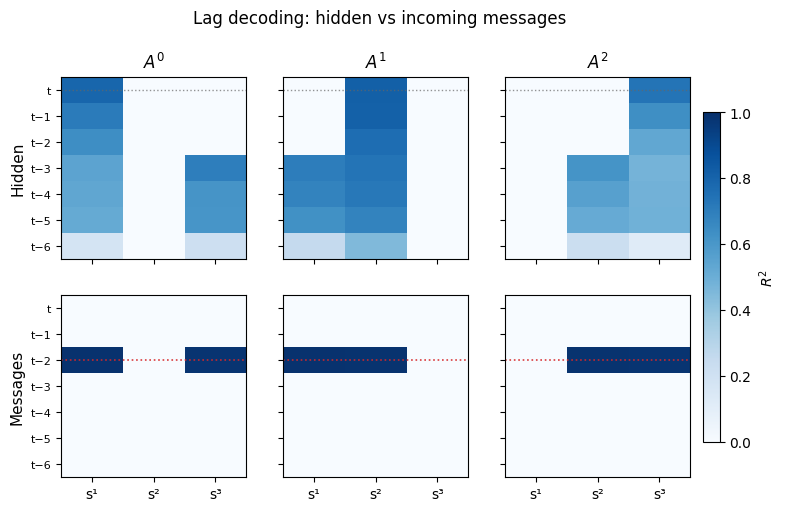

In [ ]:
# Compact comparison: hidden vs message lag-decoding (2×3 heatmaps)

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

lags = np.arange(MAX_LAG + 1)
lag_ticklabels = ["t"] + [f"t−{L}" for L in lags[1:]]
sig_ticklabels = ["s¹", "s²", "s³"]

fig, axes = plt.subplots(2, 3, figsize=(8.5, 5.2), sharex=True, sharey=True)
norm = Normalize(vmin=0, vmax=1)

for col, area in enumerate(AREAS):
    for row, (mat, row_lab) in enumerate(
        [(scores[area], "Hidden"), (msg_scores[area], "Messages")]
    ):
        ax = axes[row, col]
        im = ax.imshow(mat, aspect="auto", cmap="Blues", norm=norm, interpolation="nearest")
        ax.set_xticks(range(3))
        ax.set_xticklabels(sig_ticklabels, fontsize=10)
        ax.set_yticks(lags)
        ax.set_yticklabels(lag_ticklabels, fontsize=8)
        if col == 0:
            ax.set_ylabel(row_lab, fontsize=11)
        if row == 0:
            ax.set_title(SIGNAL_AREAS[col], fontsize=12)
        # mark expected message peak lag
        if row == 1:
            ax.axhline(cfg_lag, color="C3", ls=":", lw=1.2, alpha=0.9)
        else:
            ax.axhline(0, color="#666666", ls=":", lw=1.0, alpha=0.7)

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label=r"$R^2$")
fig.suptitle("Lag decoding: hidden vs incoming messages", fontsize=12, y=1.01)
plt.show()


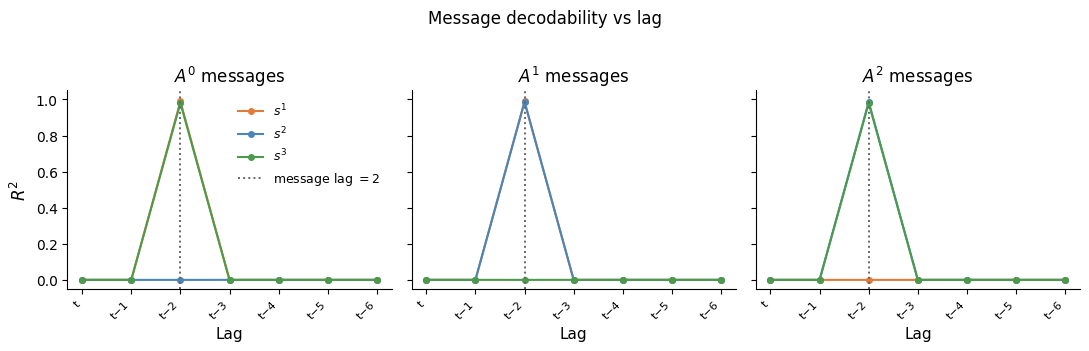

In [ ]:
# R² vs lag for incoming-message decoding (expect peak at config lag)

import matplotlib.pyplot as plt

lags = np.arange(MAX_LAG + 1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, area, area_lab in zip(axes, AREAS, SIGNAL_AREAS):
    mat = msg_scores[area]
    for sig, (sig_lab, color) in enumerate(zip(SIGNAL_LABELS, SIGNAL_COLORS)):
        ax.plot(lags, mat[:, sig], marker="o", ms=4, color=color, label=sig_lab)
    ax.axvline(
        cfg_lag,
        color="#666666",
        ls=":",
        lw=1.4,
        label=rf"message lag $={cfg_lag}$" if area == AREAS[0] else None,
    )
    ax.set_xlabel("Lag", fontsize=11)
    ax.set_title(rf"{area_lab} messages", fontsize=12)
    ax.set_xticks(lags)
    ax.set_xticklabels(["t"] + [f"t−{L}" for L in lags[1:]], fontsize=8, rotation=45, ha="right")
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(r"$R^2$", fontsize=12)
axes[0].legend(frameon=False, fontsize=9, loc="upper right")
fig.suptitle("Message decodability vs lag", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


A0 (4 slots): {'$s^1$@t': 0.791, '$s^1$@t-1': 0.71, '$s^3$@t-3': 0.696, '$s^3$@t-4': 0.612}  mean=0.702
A1 (4 slots): {'$s^1$@t-3': 0.702, '$s^1$@t-4': 0.679, '$s^2$@t': 0.813, '$s^2$@t-1': 0.809}  mean=0.750
A2 (4 slots): {'$s^2$@t-3': 0.616, '$s^2$@t-4': 0.56, '$s^3$@t': 0.737, '$s^3$@t-1': 0.634}  mean=0.637


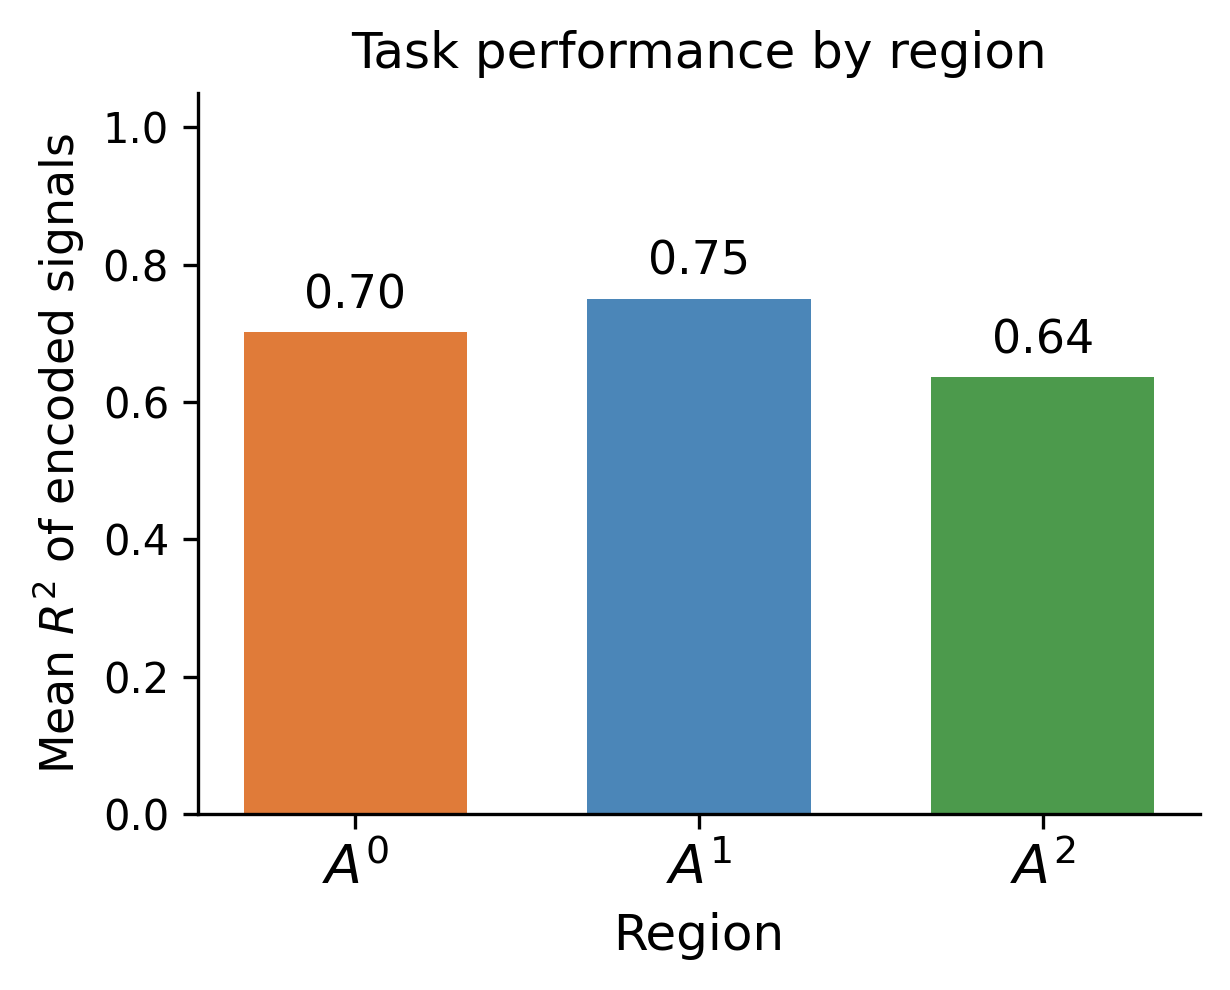

In [45]:
# Task performance by region: mean R² over expected (signal, lag) slots
# Own: lags 0 .. memory-1; cross-area: lags (lag+1) .. (lag+memory)
# With memory=2 → 2 signals × 2 lags = 4 values averaged per region

import yaml
import matplotlib.pyplot as plt

hps = yaml.safe_load((run_dir / "hparams.yaml").read_text())
connectome = np.asarray(hps["connectome"], dtype=int)
cfg_lag = int(hps["lag"])
cfg_memory = int(hps["memory"])

region_r2 = []
for a_idx, area in enumerate(AREAS):
    mat = scores[area]  # (lag, signal)
    vals = []
    details = []
    for src in range(connectome.shape[0]):
        if not connectome[a_idx, src]:
            continue
        if src == a_idx:
            lags = list(range(cfg_memory))  # own: t, t-1, ...
        else:
            # cross: first hop at lag+1, then memory depth
            start = cfg_lag + 1
            lags = list(range(start, start + cfg_memory))
        for L in lags:
            if L >= mat.shape[0]:
                raise ValueError(f"Need MAX_LAG >= {L} to cover memory slots")
            r2 = float(mat[L, src])
            vals.append(r2)
            details.append(f"{SIGNAL_LABELS[src]}@t-{L}" if L else f"{SIGNAL_LABELS[src]}@t")
    region_r2.append(float(np.mean(vals)))
    print(f"{area} ({len(vals)} slots): {dict(zip(details, [round(v, 3) for v in vals]))}  mean={region_r2[-1]:.3f}")

fig, ax = plt.subplots(figsize=(4.2, 3.4), dpi=300)
x = np.arange(len(AREAS))
bars = ax.bar(x, region_r2, color=SIGNAL_COLORS, width=0.65, edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(SIGNAL_AREAS, fontsize=13)
ax.set_ylabel(rf"Mean $R^2$ of encoded signals", fontsize=11)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Task performance by region", fontsize=12)
for bar, val in zip(bars, region_r2):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
            ha="center", va="bottom", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()


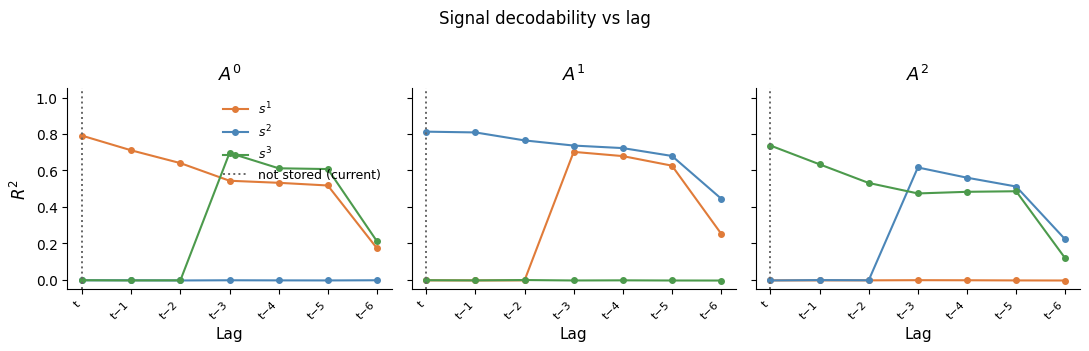

In [39]:
# R² vs lag per region; dotted line = current time (not stored in memory)

import yaml
import matplotlib.pyplot as plt

hps = yaml.safe_load((run_dir / "hparams.yaml").read_text())
no_store_lag = 0  # live input at t — available without memory storage

lags = np.arange(MAX_LAG + 1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, area, area_lab in zip(axes, AREAS, SIGNAL_AREAS):
    mat = scores[area]
    for sig, (sig_lab, color) in enumerate(zip(SIGNAL_LABELS, SIGNAL_COLORS)):
        ax.plot(lags, mat[:, sig], marker="o", ms=4, color=color, label=sig_lab)
    ax.axvline(
        no_store_lag,
        color="#666666",
        ls=":",
        lw=1.4,
        label="not stored (current)" if area == AREAS[0] else None,
    )
    ax.set_xlabel("Lag", fontsize=11)
    ax.set_title(area_lab, fontsize=13)
    ax.set_xticks(lags)
    ax.set_xticklabels(["t"] + [f"t−{L}" for L in lags[1:]], fontsize=8, rotation=45, ha="right")
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(r"$R^2$", fontsize=12)
axes[0].legend(frameon=False, fontsize=9, loc="upper right")
fig.suptitle("Signal decodability vs lag", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


A0: within mean=-0.000  |  across pair mean≈ see panel
A1: within mean=0.001  |  across pair mean≈ see panel
A2: within mean=-0.003  |  across pair mean≈ see panel
  $A^1$ vs $A^2$: mean=0.000
  $A^1$ vs $A^3$: mean=0.000
  $A^2$ vs $A^3$: mean=0.000


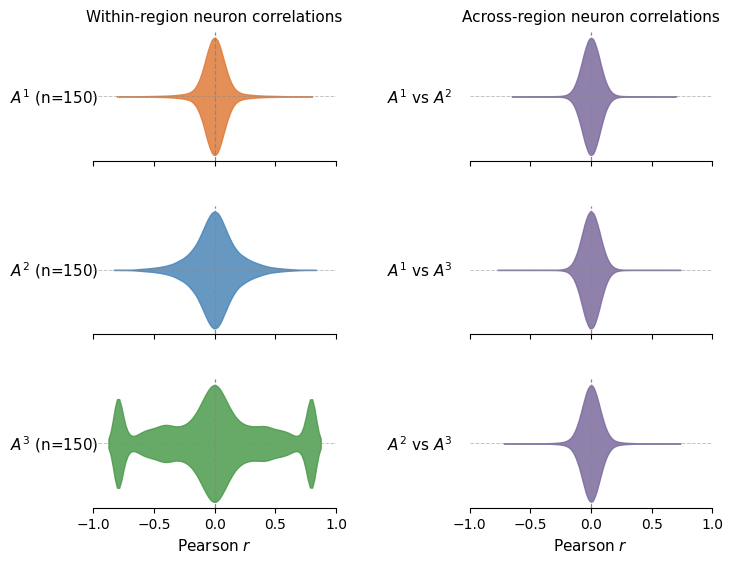

In [46]:
# Within- vs across-region neuron correlations (paper-style horizontal violins)

import matplotlib.pyplot as plt
from src.evals.eval_utils import load_session_arrays

# Continuous activity (gaussian) — better for Pearson r than Poisson counts
gauss_path = run_dir / "gaussian.h5"
corr_arrays = load_session_arrays(gauss_path) if gauss_path.exists() else arrays

AREAS = ["A0", "A1", "A2"]
AREA_LABELS = [r"$A^1$", r"$A^2$", r"$A^3$"]  # paper indexing
WITHIN_COLORS = ["#E07B39", "#4B86B8", "#4C9A4C"]
ACROSS_COLOR = "#7B6B9E"

# All neurons; subsample trials only (pairwise corr cost scales with n_neurons²)
n_trial_sample = 80
rng = np.random.default_rng(0)

n_trials = corr_arrays["area-A0"].shape[0]
n_neurons = corr_arrays["area-A0"].shape[2]
trial_idx = rng.choice(n_trials, min(n_trial_sample, n_trials), replace=False)

activity = {
    a: corr_arrays[f"area-{a}"][trial_idx]  # (trials, time, all neurons)
    for a in AREAS
}


def within_corrs(X):
    """Per-trial upper-triangle pairwise correlations. X: (trials, time, neurons)."""
    vals = []
    for t in range(X.shape[0]):
        C = np.corrcoef(X[t].T)
        i, j = np.triu_indices(C.shape[0], k=1)
        vals.append(C[i, j])
    return np.concatenate(vals)


def across_corrs(X, Y):
    """Per-trial all pairwise correlations between two regions."""
    vals = []
    for t in range(X.shape[0]):
        # corrcoef on concatenated neurons; take cross-block
        Z = np.concatenate([X[t], Y[t]], axis=1)  # (time, n_x+n_y)
        C = np.corrcoef(Z.T)
        n_x = X.shape[-1]
        vals.append(C[:n_x, n_x:].ravel())
    return np.concatenate(vals)


within = [within_corrs(activity[a]) for a in AREAS]
across_pairs = [("A0", "A1"), ("A0", "A2"), ("A1", "A2")]
across = [across_corrs(activity[a], activity[b]) for a, b in across_pairs]
across_labels = [
    rf"{AREA_LABELS[AREAS.index(a)]} vs {AREA_LABELS[AREAS.index(b)]}"
    for a, b in across_pairs
]

fig, axes = plt.subplots(3, 2, figsize=(7.2, 5.8), sharex="col")
fig.subplots_adjust(wspace=0.55, hspace=0.35, left=0.12, right=0.98, top=0.90, bottom=0.08)

for row in range(3):
    # Within
    ax = axes[row, 0]
    parts = ax.violinplot(
        within[row], positions=[0], vert=False, widths=0.85,
        showmeans=False, showextrema=False, showmedians=False,
    )
    for b in parts["bodies"]:
        b.set_facecolor(WITHIN_COLORS[row])
        b.set_edgecolor(WITHIN_COLORS[row])
        b.set_alpha(0.85)
    ax.axvline(0, color="#888888", ls="--", lw=0.9)
    ax.axhline(0, color="#888888", ls="--", lw=0.7, alpha=0.5)
    ax.set_yticks([])
    ax.set_ylabel(rf"{AREA_LABELS[row]} (n={n_neurons})", fontsize=11, rotation=0, labelpad=28, va="center")
    ax.set_xlim(-1, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Across
    ax = axes[row, 1]
    parts = ax.violinplot(
        across[row], positions=[0], vert=False, widths=0.85,
        showmeans=False, showextrema=False, showmedians=False,
    )
    for b in parts["bodies"]:
        b.set_facecolor(ACROSS_COLOR)
        b.set_edgecolor(ACROSS_COLOR)
        b.set_alpha(0.85)
    ax.axvline(0, color="#888888", ls="--", lw=0.9)
    ax.axhline(0, color="#888888", ls="--", lw=0.7, alpha=0.5)
    ax.set_yticks([])
    ax.set_ylabel(across_labels[row], fontsize=11, rotation=0, labelpad=36, va="center")
    ax.set_xlim(-1, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

axes[0, 0].set_title("Within-region neuron correlations", fontsize=11, pad=8)
axes[0, 1].set_title("Across-region neuron correlations", fontsize=11, pad=8)
axes[-1, 0].set_xlabel(r"Pearson $r$", fontsize=11)
axes[-1, 1].set_xlabel(r"Pearson $r$", fontsize=11)

for a, w, ac in zip(AREAS, within, across):
    print(f"{a}: within mean={np.nanmean(w):.3f}  |  across pair mean≈ see panel")
for lab, ac in zip(across_labels, across):
    print(f"  {lab}: mean={np.nanmean(ac):.3f}")

plt.show()


In [ ]:
# Population activity heatmaps: firing rates (gaussian, grayscale) + spike counts (poisson)

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, PowerNorm

AREAS = ["A0", "A1", "A2"]
AREA_LABELS = [r"$A^0$", r"$A^1$", r"$A^2$"]
TRIAL_IDX = 0
RATE_MAX = 40.0
BIN_DT_S = 0.01  # 10 ms bins -> 200 steps = 2 s

with h5py.File(run_dir / "gaussian.h5", "r") as h:
    continuous = {a: h["0"][f"area-{a}"][TRIAL_IDX] for a in AREAS}  # (T, N)

# data.h5 areas are already poisson spike counts for this run
counts = {a: arrays[f"area-{a}"][TRIAL_IDX] for a in AREAS}  # (T, N)

rates = {
    a: np.clip(RATE_MAX * (continuous[a] + 1.0) / 2.0, 0.0, RATE_MAX)
    for a in AREAS
}

T = continuous["A0"].shape[0]
time_s = np.arange(T) * BIN_DT_S


def plot_area_heatmaps(data_by_area, *, cmap, cbar_label, vmin=None, vmax=None, norm=None, cbar_ticks=None):
    fig = plt.figure(figsize=(14, 6.5), dpi=300)
    gs = fig.add_gridspec(
        len(AREAS),
        2,
        width_ratios=[1.0, 0.03],
        wspace=0.05,
        hspace=0.08,
    )
    axes = [fig.add_subplot(gs[i, 0]) for i in range(len(AREAS))]
    cax = fig.add_subplot(gs[:, 1])  # colorbar spans all 3 panels

    im = None
    for ax, area, label in zip(axes, AREAS, AREA_LABELS):
        Z = data_by_area[area].T  # (N, T)
        kwargs = dict(
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            cmap=cmap,
            extent=[time_s[0], time_s[-1] + BIN_DT_S, 0, Z.shape[0]],
        )
        if norm is not None:
            kwargs["norm"] = norm
        else:
            kwargs["vmin"] = vmin
            kwargs["vmax"] = vmax
        im = ax.imshow(Z, **kwargs)
        ax.set_ylabel(label, rotation=0, labelpad=24, va="center", fontsize=18, fontweight="bold")
        ax.set_yticks([])
        ax.set_xticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[-1].set_xlabel("Time (s)", fontsize=16)
    axes[-1].set_xlim(time_s[0], time_s[-1] + BIN_DT_S)
    axes[-1].set_xticks([0.0, 1.0, 2.0])
    axes[-1].set_xticklabels(["0.0", "1.0", "2.0"])
    axes[-1].tick_params(axis="x", which="both", length=0, labelbottom=True, labelsize=14)
    for tick, ha in zip(axes[-1].xaxis.get_majorticklabels(), ["left", "center", "right"]):
        tick.set_horizontalalignment(ha)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(cbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=14, length=0)
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
    # Align edge colorbar labels with the bar (bottom/top flush)
    cbar_labels = cbar.ax.yaxis.get_majorticklabels()
    if len(cbar_labels) >= 2:
        cbar_labels[0].set_verticalalignment("bottom")
        cbar_labels[-1].set_verticalalignment("top")
        for tick in cbar_labels[1:-1]:
            tick.set_verticalalignment("center")
    return fig


# Figure 1: firing rates — white (low) -> black (high)
fig_rates = plot_area_heatmaps(
    rates,
    cmap="Greys",
    cbar_label="Firing rate (Hz)",
    norm=PowerNorm(gamma=2.5, vmin=0.0, vmax=RATE_MAX),
    cbar_ticks=[0, 10, 20, 30, 40],
)
plt.show()

# Figure 2: spike counts (Blues)
count_vmax = min(12, int(np.max([counts[a].max() for a in AREAS])))
fig_counts = plot_area_heatmaps(
    counts,
    cmap="Blues",
    cbar_label="Spike count (per bin)",
    vmin=0.0,
    vmax=count_vmax,
)
plt.show()
